# Required packages

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [43]:
import warnings
warnings.filterwarnings('ignore')
from tqdm.notebook import tqdm
from itertools import product
from typing import Union

In [44]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# 11.1) Importing the required libraries and loading the data

In [45]:
df = pd.read_csv('data/AusAntidiabeticDrug.csv')
df['ds'] = pd.to_datetime(df['ds'])
df = df.set_index('ds')
df = df.asfreq('MS')

In [46]:
df.head()

,y
ds,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869


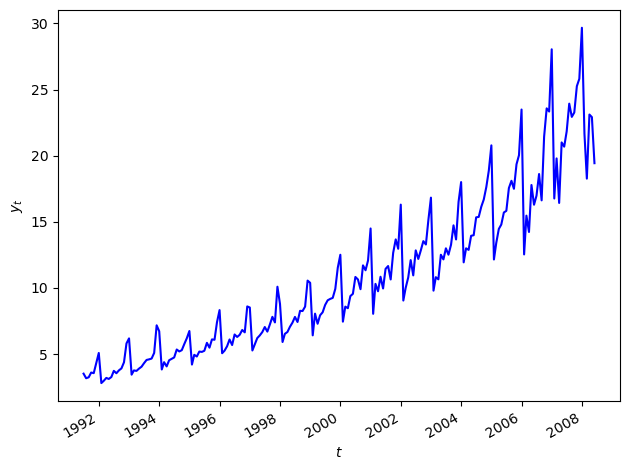

In [47]:
fig, ax = plt.subplots()
ax.plot(df['y'], 'b-')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

# 11.2) Visualizing the series and its components

In [48]:
decomposition = STL(df.y, period=12).fit()

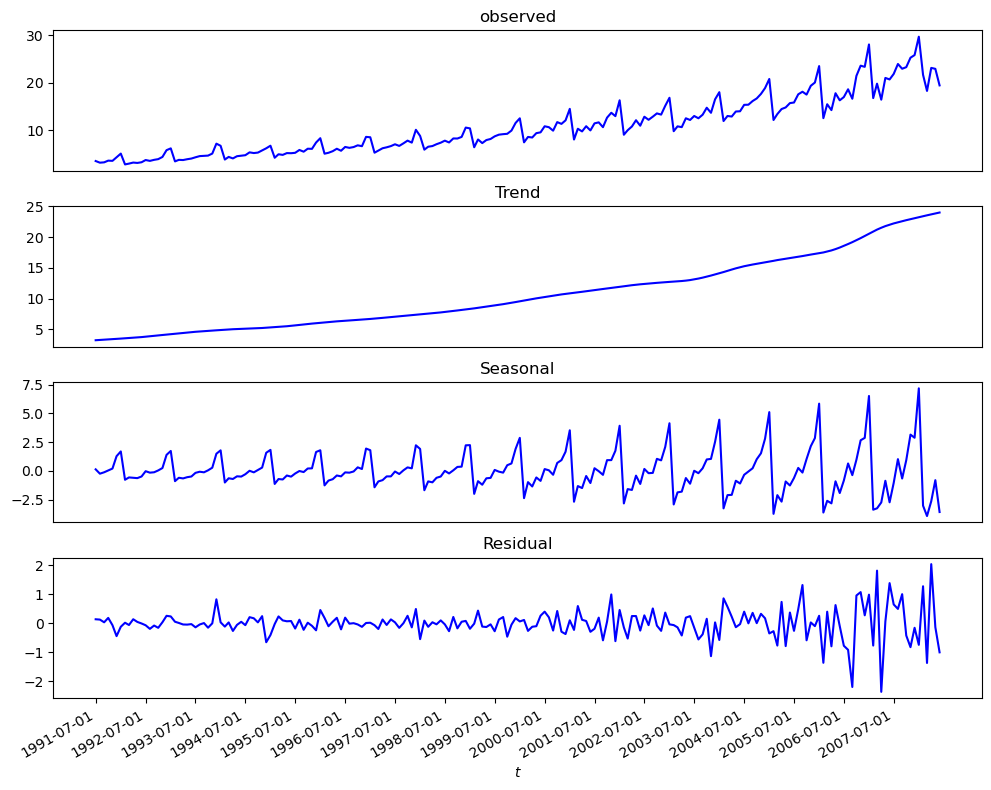

In [49]:
fig, ax = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10, 8))
ax[0].plot(decomposition.observed, 'b-')
ax[0].xaxis.set_ticks_position('none')
ax[0].set_title('observed')

ax[1].plot(decomposition.trend, 'b-')
ax[1].xaxis.set_ticks_position('none')
ax[1].set_title('Trend')

ax[2].plot(decomposition.seasonal, 'b-')
ax[2].xaxis.set_ticks_position('none')
ax[2].set_title('Seasonal')

ax[3].plot(decomposition.resid, 'b-')
ax[3].set_xticks(df.index[::12])
ax[3].set_xlabel('$t$')
ax[3].set_title('Residual')

fig.autofmt_xdate()
fig.tight_layout()
fig.savefig('figuras/decomposition_chapter_11.png')
fig.savefig('figuras/decomposition_chapter_11.pdf')
fig.savefig('figuras/decomposition_chapter_11.svg')
plt.show()

# 11.3) Modeling the data

In [50]:
adfuller(df.y)

(np.float64(3.1451856893067336),
 1.0,
 15,
 188,
 {'1%': np.float64(-3.465620397124192),
  '5%': np.float64(-2.8770397560752436),
  '10%': np.float64(-2.5750324547306476)},
 np.float64(549.6705685364174))

## Testing $d=1$

In [51]:
y_diff = np.diff(df.y)
adfuller(y_diff)

(np.float64(-2.495172147449721),
 np.float64(0.11665341686469227),
 15,
 187,
 {'1%': np.float64(-3.465811691080702),
  '5%': np.float64(-2.877123351472649),
  '10%': np.float64(-2.5750770662586864)},
 np.float64(547.1880809726356))

## Testing $D=1$

In [52]:
adfuller(np.diff(y_diff, n=12))

(np.float64(-19.848440097313564),
 0.0,
 15,
 175,
 {'1%': np.float64(-3.4682803641749267),
  '5%': np.float64(-2.8782017240816327),
  '10%': np.float64(-2.5756525795918366)},
 np.float64(1526.2892092546822))

## 11.3.1) Performing model selection

In [53]:
train = df.y[:-36]
test = df.y[-36:]

In [54]:
len(test)

36

In [55]:
def optimize_sarima(series: Union[list, pd.Series, tuple], order_list: Union[list, tuple], s: int = 12) -> pd.DataFrame:
    """
    Choose the p, q, P, Q parameters in the SARIMA model.

    Params:
    -------
    series: Union[list, pd.Series, tuple]
        time series 
    order_list: Union[list, tuple]
        a list with all options of p, d, q, P, D,  Q
    s: int
        seasonal frequency (size of seasonal period). Defaults to 12.

    Returns:
    -------
        a dataframe with eight columns: p, d, q, P, D, Q, m, AIC
    """

    results = []
    for order in tqdm(order_list):
        try:
            model = SARIMAX(
                series, order = order[:3], seasonal_order=(*order[3:], s)
            ).fit(disp=False)
            results.append([*order, s, model.aic])
        except:
            continue
        

    return pd.DataFrame(
        results,
        columns=['p', 'd', 'q', 'P', 'D', 'Q', 'm', 'AIC']
    ).sort_values(by='AIC', ascending=True).reset_index(drop=True)

In [56]:
orderlist = list(product(
    range(4), [1], range(4), range(4), [1], range(4)
))

In [57]:
orderlist[:2]

[(0, 1, 0, 0, 1, 0), (0, 1, 0, 0, 1, 1)]

df = optimize_sarima(train, orderlist)

df.to_csv('data/chapter_11_aic.csv')

In [58]:
df_aic = pd.read_csv('data/chapter_11_aic.csv', index_col=0)

In [59]:
df_aic.head()

,p,d,q,P,D,Q,m,AIC
0,3,1,1,1,1,3,12,270.951095
1,3,1,3,1,1,3,12,271.347831
2,3,1,2,1,1,3,12,272.222637
3,3,1,3,0,1,1,12,272.580413
4,3,1,3,2,1,0,12,272.949439


## 11.3.2) Conducting residual analysis

In [60]:
model = SARIMAX(
    train, order=(3, 1, 1), seasonal_order=(1, 1, 3, 12), simple_differencing=False
).fit(disp=False)

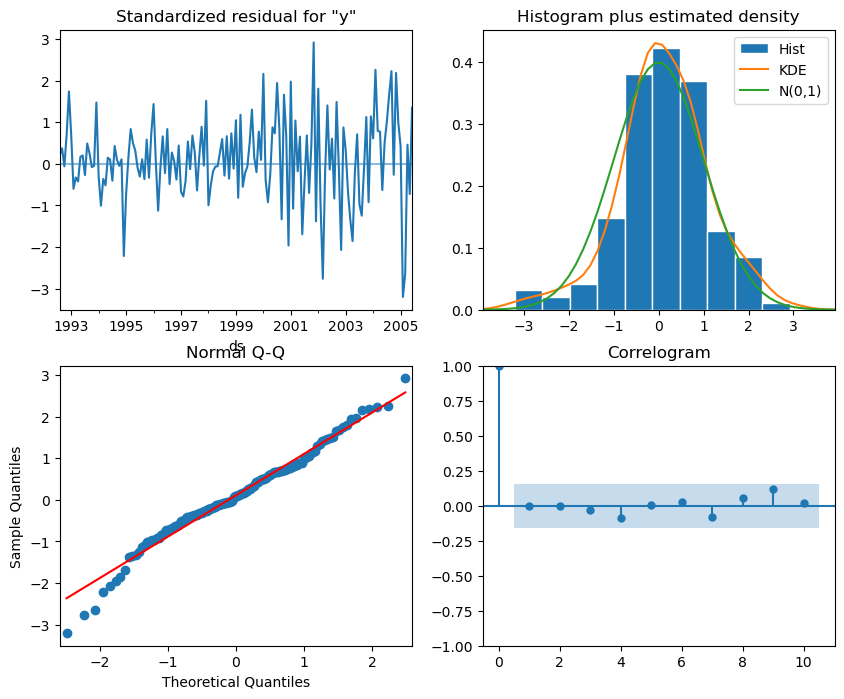

In [61]:
model.plot_diagnostics(figsize=(10, 8));

In [62]:
residuals = model.resid

In [63]:
df_ljungbox = acorr_ljungbox(residuals, lags=20)

In [64]:
df_ljungbox

,lb_stat,lb_pvalue
1,0.436501,0.508816
2,0.627118,0.730841
3,0.645644,0.885908
4,2.257725,0.688476
5,2.949893,0.707711
6,3.388781,0.758703
7,9.981254,0.189638
8,10.591193,0.225955
9,11.853200,0.221712
10,11.984546,0.286092


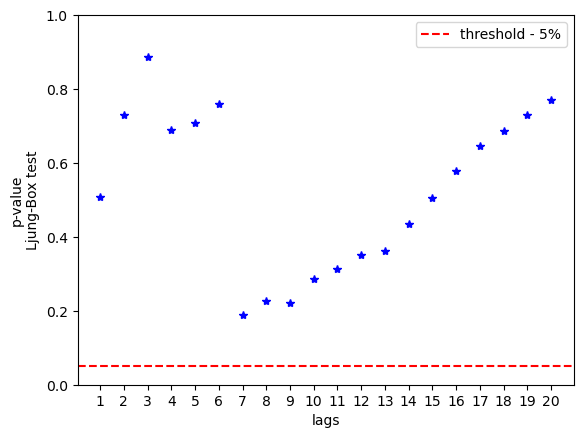

In [65]:
fig, ax = plt.subplots()
ax.plot(df_ljungbox.lb_pvalue, 'b*')
ax.set_ylim([0,1])
ax.axhline(0.05, color='r', linestyle='--', label='threshold - 5%')
ax.set_xticks(np.arange(1, 21))
ax.set_xlabel('lags')
ax.set_ylabel('p-value\nLjung-Box test')
ax.legend()
plt.show()

# 11.4) Forecasting and evaluating model's performance

In [74]:
def recursive_forecast(
    endog: Union[pd.Series, list], 
    train_len: int, horizon: int, window:int,
    method: str, 
    order: Union[tuple, list] = (3, 1, 1),
    seasonal_order: Union[tuple, list] = (1, 1, 3, 12)
) -> list:
    """
    Recursive forecast to evaluate the forecasting methods.

    Params:
    --------
    endog: Union[pd.Series, list]
        Endogenous time series.
    train_len: int
        Sample size used to train.
    horizon: int
        Horizon to forecast.
    window:
        Window of forecast.
    method:
        Prediction method. Must be either 'last_season' or 'sarimax'.
    order: Union[tuple, list]
        ARIMA order of SARIMAX.
    seasonal_order: Union[tuple, list]
        Seasonal order of SARIMAX.

    Returns:
    ---------
        A list with horizon elements.
    """
    total_len = train_len + horizon

    if method == 'last_season':
        pred = []

        for i in tqdm(range(train_len, total_len, window), desc='Last season'):
            last_values = endog[:i].iloc[-window:]
            pred.extend(last_values)
        return pred
    elif method == 'sarimax':
        pred = []
        
        for i in tqdm(range(train_len, total_len, window), desc='SARIMAX'):
            model = SARIMAX(
                endog[:i], order = order, seasonal_order=seasonal_order, simple_differencing=False
            ).fit(disp=False)
            predictions = model.get_prediction(0, i + window - 1).predicted_mean
            pred.extend(predictions[-window:])
        return pred
            
    else:
        raise Exception("'method' must be 'last' or 'sarimax'.")

In [75]:
print(f'{len(train)=} | {len(test)=}')

len(train)=168 | len(test)=36


In [76]:
TRAIN_LEN = 168
HORIZON = 36
WINDOW = 12

In [77]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 204 entries, 1991-07-01 to 2008-06-01
Freq: MS
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   y       204 non-null    float64
dtypes: float64(1)
memory usage: 3.2 KB


In [78]:
help(recursive_forecast)

Help on function recursive_forecast in module __main__:

recursive_forecast(
    endog: Union[pd.Series, list],
    train_len: int,
    horizon: int,
    window: int,
    method: str,
    order: Union[tuple, list] = (3, 1, 1),
    seasonal_order: Union[tuple, list] = (1, 1, 3, 12)
) -> list
    Recursive forecast to evaluate the forecasting methods.

    Params:
    --------
    endog: Union[pd.Series, list]
        Endogenous time series.
    train_len: int
        Sample size used to train.
    horizon: int
        Horizon to forecast.
    window:
        Window of forecast.
    method:
        Prediction method. Must be either 'last_season' or 'sarimax'.
    order: Union[tuple, list]
        ARIMA order of SARIMAX.
    seasonal_order: Union[tuple, list]
        Seasonal order of SARIMAX.

    Returns:
    ---------
        A list with horizon elements.



In [81]:
df_pred = pd.DataFrame({
    'Observed': test,
    'Last season': recursive_forecast(df['y'], TRAIN_LEN, HORIZON, WINDOW, 'last_season'),
    'SARIMAX': recursive_forecast(df['y'], TRAIN_LEN, HORIZON, WINDOW, 'sarimax')
})

Last season:   0%|          | 0/3 [00:00<?, ?it/s]

SARIMAX:   0%|          | 0/3 [00:00<?, ?it/s]

In [82]:
df_pred.head()

,Observed,Last season,SARIMAX
ds,,,
2005-07-01,15.829550,15.339097,16.745888
2005-08-01,17.554701,15.370764,16.619384
2005-09-01,18.100864,16.142005,17.255371
2005-10-01,17.496668,16.685754,18.107578
2005-11-01,19.347265,17.636728,18.722300


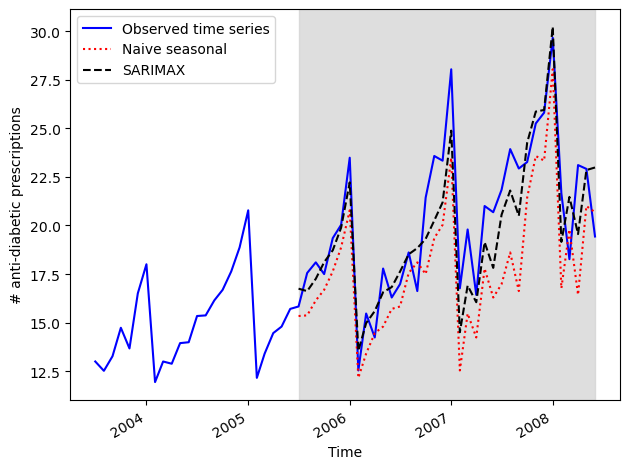

In [93]:
fig, ax = plt.subplots()
ax.plot(df['y'].iloc[144:], 'b-', label='Observed time series')
ax.plot(df_pred['Last season'], 'r:', label='Naive seasonal')
ax.plot(df_pred['SARIMAX'], 'k--', label='SARIMAX')
ax.axvspan(df_pred.index[0], df_pred.index[-1], color='lightgray', alpha=0.75)
ax.legend()

ax.set_xlabel('Time')
ax.set_ylabel('# anti-diabetic prescriptions')

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

In [94]:
mape = lambda y, p: np.mean(np.abs((y-p) / p) * 100)

In [95]:
series_mape = pd.Series({
    'Naive seasonal': mape(df_pred['Observed'], df_pred['Last season']),
    'SARIMAX': mape(df_pred['Observed'], df_pred['SARIMAX'])
})

In [96]:
series_mape

Naive seasonal    15.305059
SARIMAX            7.909484
dtype: float64

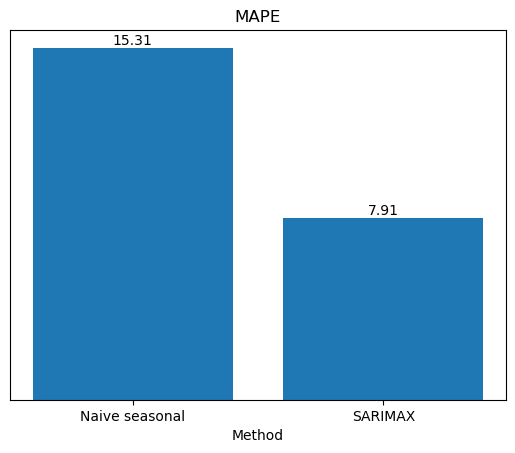

In [99]:
fig, ax = plt.subplots()
bars = ax.bar(series_mape.index, series_mape.values)
ax.bar_label(bars, fmt='%0.2f')
ax.set_xlabel('Method')
ax.set_title('MAPE')
ax.set_yticks([])
plt.show()